# 05 · Model validation

Compares base cpsam against all available fine-tuned models on a held-out
validation split image. Produces the same figures as `sockeye_finetune.py`
so runs are directly comparable.

**Prerequisites:**
- Run `sockeye_inference.py` on the chosen val image to generate patches
- Annotate the val image patches in the Cellpose GUI and save `_seg.npy` files
- At least one fine-tuned model in `models/finetuned/`

**Outputs** (under `figures/validation/<stem>/`):
- `val_comparison.png` — image + masks for each model
- `ap_bars.png` — per-patch AP @ IoU 0.5
- `cell_counts.png` — ground truth vs each model

**Environment:** `cellpose`

04/23/2026 running on Scene-02-20260416-C3M2_Tcol_2-A01Export-04_c1-4_stack.tif, which is a validation image run through the "inference" pipeline with the --single flag. Comparing base,  v0 (1stack), v1 (5 stacks), v2 ()

In [1]:
import json
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path
from aquarel import load_theme
from cellpose import models, metrics, utils

import sys
PROJECT_ROOT = Path('/Users/alicehong/projects/cellpose-biosensor')
sys.path.insert(0, str(PROJECT_ROOT))
from src.io import split_image, stitch_masks

In [7]:
# Config
# Image must be in splits["val"] and have annotated _seg.npy files in data/patches/
VAL_IMAGE   = 'Scene-02-20260416-C3M2_Tcol_2-A01Export-04_c1-4_stack.tif'   # ← change this

N_ROWS      = 3
N_COLS      = 3
N_SHOW      = 3        # patches to show in val comparison figure
MIN_CELLS   = 3        # skip patches with fewer annotated cells
DIAMETER_PX = round(1.5 / 0.035)  # 43 px
AQUAREL_THEME = 'boxy_light'

PATCHES_DIR = PROJECT_ROOT / 'data' / 'patches' / 'v1'
RUNS_DIR    = PROJECT_ROOT / 'models' / 'finetuned'
FIG_DIR     = PROJECT_ROOT / 'figures' / 'validation' / Path(VAL_IMAGE).stem
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures → {FIG_DIR}')

Figures → /Users/alicehong/projects/cellpose-biosensor/figures/validation/Scene-02-20260416-C3M2_Tcol_2-A01Export-04_c1-4_stack


## Discover fine-tuned models

In [3]:
# Auto-discover all runs in models/finetuned/ that contain a model file
run_models = {}   # run_name → model path
for run_dir in sorted(RUNS_DIR.iterdir()):
    if not run_dir.is_dir():
        continue
    model_files = list((run_dir / 'models').glob('*')) if (run_dir / 'models').exists() else []
    if not model_files:
        continue
    run_models[run_dir.name] = model_files[0]   # one model per run
    info_path = run_dir / 'run_info.json'
    if info_path.exists():
        info = json.loads(info_path.read_text())
        print(f'  {run_dir.name:<15}  {model_files[0].name:<25}  '
              f'AP base={info.get("ap_base","?"):.3f}  '
              f'AP ft={info.get("ap_finetuned","?"):.3f}  '
              f'({info.get("n_train_patches","?")} train patches)')
    else:
        print(f'  {run_dir.name:<15}  {model_files[0].name}')

print(f'\n{len(run_models)} fine-tuned model(s) found + base cpsam')

  1stack           cpsam_finetuned
  5stacks          cpsam_5stacks              AP base=0.884  AP ft=0.842  (35 train patches)

2 fine-tuned model(s) found + base cpsam


## Load ground truth patches

In [8]:
stem      = Path(VAL_IMAGE).stem
patch_dir = PATCHES_DIR / stem
assert patch_dir.exists(), (
    f'{patch_dir} not found — run sockeye_inference.py on {VAL_IMAGE} first')

val_imgs, val_masks, val_names = [], [], []
for tif in sorted(patch_dir.glob('patch_r*_c*.tif')):
    if '_masks' in tif.name:
        continue
    seg_path = tif.with_name(tif.stem + '_seg.npy')
    if not seg_path.exists():
        print(f'  Skip {tif.name} — no _seg.npy (annotate in Cellpose GUI first)')
        continue
    mask = np.load(str(seg_path), allow_pickle=True).item()['masks'].astype(np.int32)
    if mask.max() < MIN_CELLS:
        print(f'  Skip {tif.name} — only {mask.max()} cells < {MIN_CELLS}')
        continue
    val_imgs.append(tifffile.imread(str(tif)).astype(np.float32))
    val_masks.append(mask)
    val_names.append(tif.stem)

assert len(val_imgs) >= 1, 'No annotated patches found — annotate the val image first'
print(f'\nLoaded {len(val_imgs)} annotated patches')
for name, mask in zip(val_names, val_masks):
    print(f'  {name}: {mask.max()} cells')

  Skip patch_r0_c0.tif — only 2 cells < 3

Loaded 8 annotated patches
  patch_r0_c1: 66 cells
  patch_r0_c2: 150 cells
  patch_r1_c0: 20 cells
  patch_r1_c1: 58 cells
  patch_r1_c2: 29 cells
  patch_r2_c0: 17 cells
  patch_r2_c1: 49 cells
  patch_r2_c2: 38 cells


## Run inference — all models

In [9]:
eval_kw = dict(diameter=DIAMETER_PX, channels=[0, 0],
               flow_threshold=0.4, cellprob_threshold=0.0)

# Dict: model_label → list of predicted masks (one per patch)
predictions = {}

print('Running base cpsam...')
model_base = models.CellposeModel(gpu=True)
predictions['base cpsam'] = [model_base.eval(img, **eval_kw)[0] for img in val_imgs]
print(f'  done')

for run_name, model_path in run_models.items():
    print(f'Running {run_name}...')
    m = models.CellposeModel(gpu=True, pretrained_model=str(model_path))
    predictions[run_name] = [m.eval(img, **eval_kw)[0] for img in val_imgs]
    print(f'  done')

print(f'\nModels evaluated: {list(predictions.keys())}')

Running base cpsam...


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
/Users/alicehong/miniforge3/envs/cellpose/lib/python3.10/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain m

  done
Running 1stack...


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


  done
Running 5stacks...


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


  done

Models evaluated: ['base cpsam', '1stack', '5stacks']


## AP @ IoU 0.5

In [10]:
ap_per_model = {}  # model_label → array of per-patch AP values
print(f'{"Model":<20}  {"Mean AP@0.5":>12}  Per-patch')
print('-' * 60)
for label, preds in predictions.items():
    ap = metrics.average_precision(val_masks, preds)[0][:, 0]
    ap_per_model[label] = ap
    per_patch = '  '.join(f'{v:.3f}' for v in ap)
    print(f'{label:<20}  {ap.mean():>12.3f}  {per_patch}')

Model                  Mean AP@0.5  Per-patch
------------------------------------------------------------
base cpsam                   0.685  0.676  0.855  0.565  0.788  0.765  0.571  0.642  0.619
1stack                       0.625  0.675  0.801  0.586  0.707  0.558  0.536  0.568  0.571
5stacks                      0.678  0.694  0.784  0.615  0.775  0.641  0.538  0.742  0.638


## Figure: val comparison

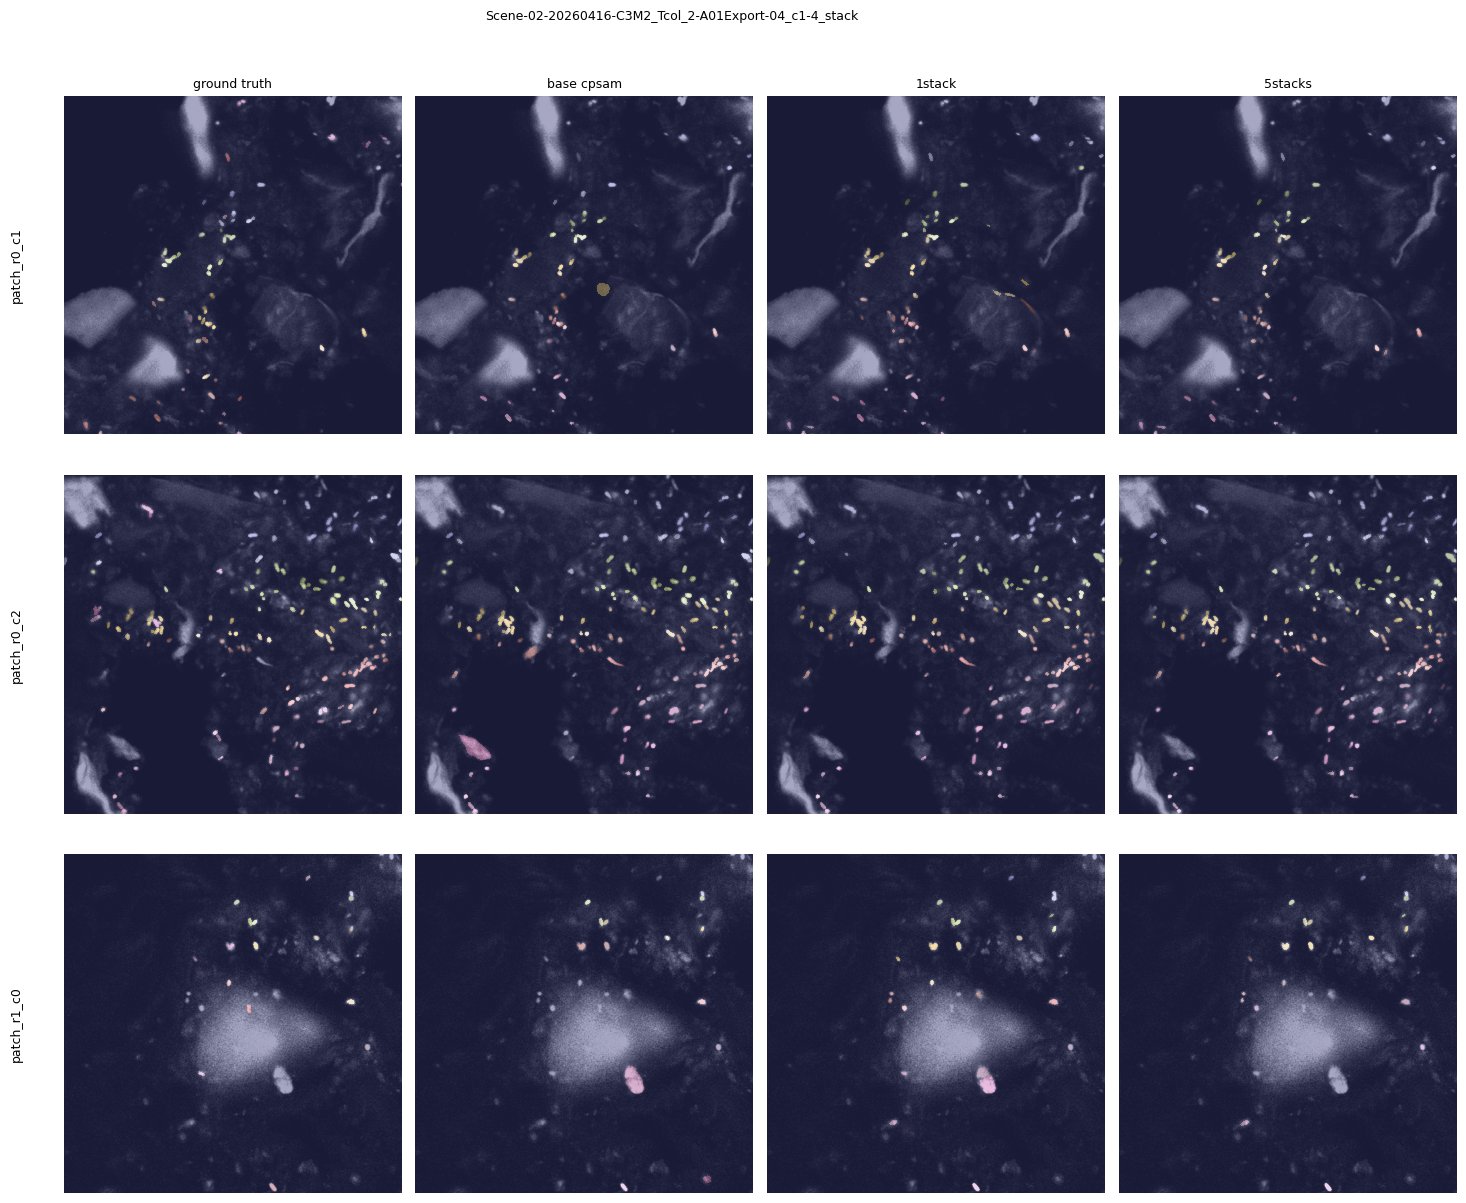

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/validation/Scene-02-20260416-C3M2_Tcol_2-A01Export-04_c1-4_stack/val_comparison.png


In [11]:
def norm(img):
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-6), 0, 1)

def show_mask(ax, img_norm, mask):
    ax.imshow(img_norm, cmap='gray', vmin=0, vmax=1)
    if mask.max() > 0:
        ax.imshow(mask, cmap='tab20b', alpha=0.45, interpolation='nearest')

model_labels = list(predictions.keys())
n_show = min(N_SHOW, len(val_imgs))
n_cols = 1 + len(model_labels)   # ground truth + one per model

fig, axes = plt.subplots(n_show, n_cols, figsize=(4 * n_cols, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for i in range(n_show):
    img_n = norm(val_imgs[i])
    show_mask(axes[i, 0], img_n, val_masks[i])
    axes[i, 0].text(-0.12, 0.5, val_names[i],
                    transform=axes[i, 0].transAxes,
                    rotation=90, va='center', ha='right', fontsize=9, clip_on=False)
    for j, label in enumerate(model_labels):
        show_mask(axes[i, j + 1], img_n, predictions[label][i])

axes[0, 0].set_title('ground truth', fontsize=9)
for j, label in enumerate(model_labels):
    axes[0, j + 1].set_title(label, fontsize=9)
for ax in axes.flat:
    ax.axis('off')

fig.suptitle(stem, fontsize=9, y=1.01)
fig.tight_layout()
fig.subplots_adjust(left=0.12)
fig.savefig(FIG_DIR / 'val_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/val_comparison.png')

## Figure: AP bars

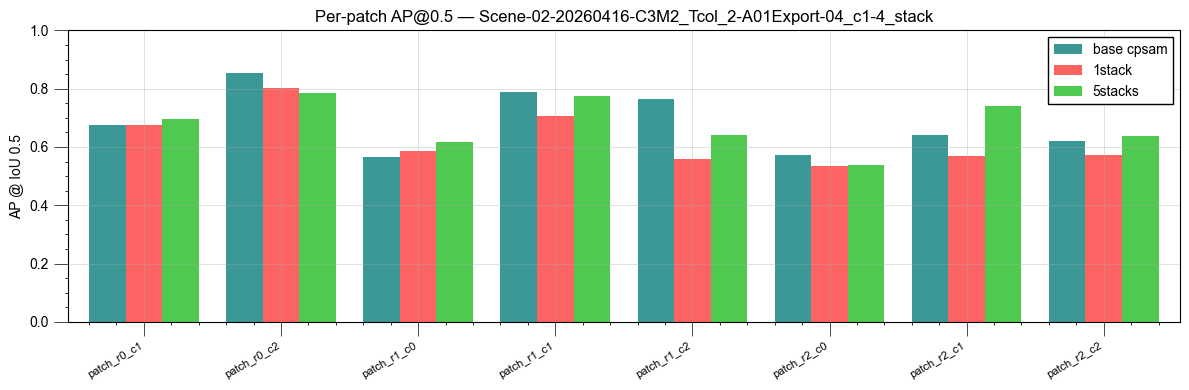

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/validation/Scene-02-20260416-C3M2_Tcol_2-A01Export-04_c1-4_stack/ap_bars.png


In [12]:
n_models = len(ap_per_model)
x = np.arange(len(val_names))
w = 0.8 / n_models
offsets = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * w

theme = load_theme(AQUAREL_THEME)
theme.apply()
fig, ax = plt.subplots(figsize=(max(6, len(val_names) * 1.5), 4))
for (label, ap), offset in zip(ap_per_model.items(), offsets):
    ax.bar(x + offset, ap, w, label=label)
ax.set_xticks(x)
ax.set_xticklabels(val_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('AP @ IoU 0.5')
ax.set_ylim(0, 1)
ax.set_title(f'Per-patch AP@0.5 — {stem}')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'ap_bars.png', dpi=150, bbox_inches='tight')
plt.show()
plt.rcdefaults()
print(f'Saved → {FIG_DIR}/ap_bars.png')

## Figure: cell counts

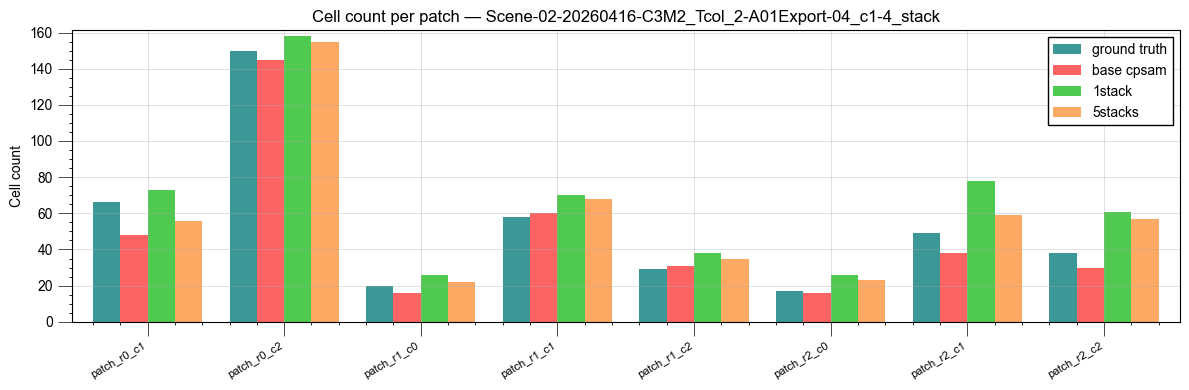

Saved → /Users/alicehong/projects/cellpose-biosensor/figures/validation/Scene-02-20260416-C3M2_Tcol_2-A01Export-04_c1-4_stack/cell_counts.png


In [13]:
all_labels  = ['ground truth'] + list(predictions.keys())
all_counts  = [[int(m.max()) for m in val_masks]] + \
              [[int(m.max()) for m in preds] for preds in predictions.values()]
n_bars = len(all_labels)
x  = np.arange(len(val_names))
w  = 0.8 / n_bars
offsets = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * w

theme = load_theme(AQUAREL_THEME)
theme.apply()
fig, ax = plt.subplots(figsize=(max(6, len(val_names) * 1.5), 4))
for label, counts, offset in zip(all_labels, all_counts, offsets):
    ax.bar(x + offset, counts, w, label=label)
ax.set_xticks(x)
ax.set_xticklabels(val_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Cell count')
ax.set_title(f'Cell count per patch — {stem}')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'cell_counts.png', dpi=150, bbox_inches='tight')
plt.show()
plt.rcdefaults()
print(f'Saved → {FIG_DIR}/cell_counts.png')

## Figure: F1 vs IoU threshold

In [ ]:
iou_thresholds = np.arange(0.5, 1.0, 0.05)

theme = load_theme(AQUAREL_THEME)
theme.apply()
fig, ax = plt.subplots(figsize=(8, 5))

for label, preds in predictions.items():
    ap_out = metrics.average_precision(val_masks, preds, threshold=iou_thresholds)
    tp = ap_out[1]   # (n_patches, n_thresholds)
    fp = ap_out[2]
    fn = ap_out[3]

    precision = tp.sum(axis=0) / np.maximum(tp.sum(axis=0) + fp.sum(axis=0), 1e-6)
    recall    = tp.sum(axis=0) / np.maximum(tp.sum(axis=0) + fn.sum(axis=0), 1e-6)
    f1        = 2 * precision * recall / np.maximum(precision + recall, 1e-6)

    ax.plot(iou_thresholds, f1, marker='o', markersize=4, label=label)

ax.set_xlabel('IoU threshold')
ax.set_ylabel('F1 score')
ax.set_title(f'F1 vs IoU threshold — {stem}')
ax.set_xlim(0.48, 1.0)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'f1_curve.png', dpi=150, bbox_inches='tight')
plt.show()
plt.rcdefaults()
print(f'Saved → {FIG_DIR}/f1_curve.png')